In [1]:
import astropy
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
from scipy.signal import savgol_filter
import pandas as pd
import numpy as np
import FunctionLib as FL
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")


config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,
    "axes.edgecolor": "black",

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,
    "ytick.minor.width": 2,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)


DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(("./DJAV4.2Catalog.pkl"))

print("="*50)
print(f"Total {(DJAv4Catalog.sample_num())} sample objectss loaded.")
print("="*50)

Total 1102 sample objectss loaded.


In [2]:
# 定义新旧路径的前缀
old_base_path = '/home/xingyaocai/DJAv4.2'
new_base_path = '/Users/xingyaocai/DJAv4.2'

# 遍历 catalog 并修改路径
for survey_id, entry in DJAv4Catalog.catalog_iterator():

    # 1. 更新 prism 文件的路径
    if entry.get('prism_filepath'):
        entry['prism_filepath'] = entry['prism_filepath'].replace(
            old_base_path, new_base_path)

    # 2. 更新 grating 文件的路径 (遍历字典)
    if entry.get('grating_filepaths'):
        for filter_name, filepath in entry['grating_filepaths'].items():
            if filepath:
                entry['grating_filepaths'][filter_name] = filepath.replace(
                    old_base_path, new_base_path)
    DJAv4Catalog.update_catalog_item(survey_id, entry)

print("文件路径地址已临时更新为本地地址！")

文件路径地址已临时更新为本地地址！


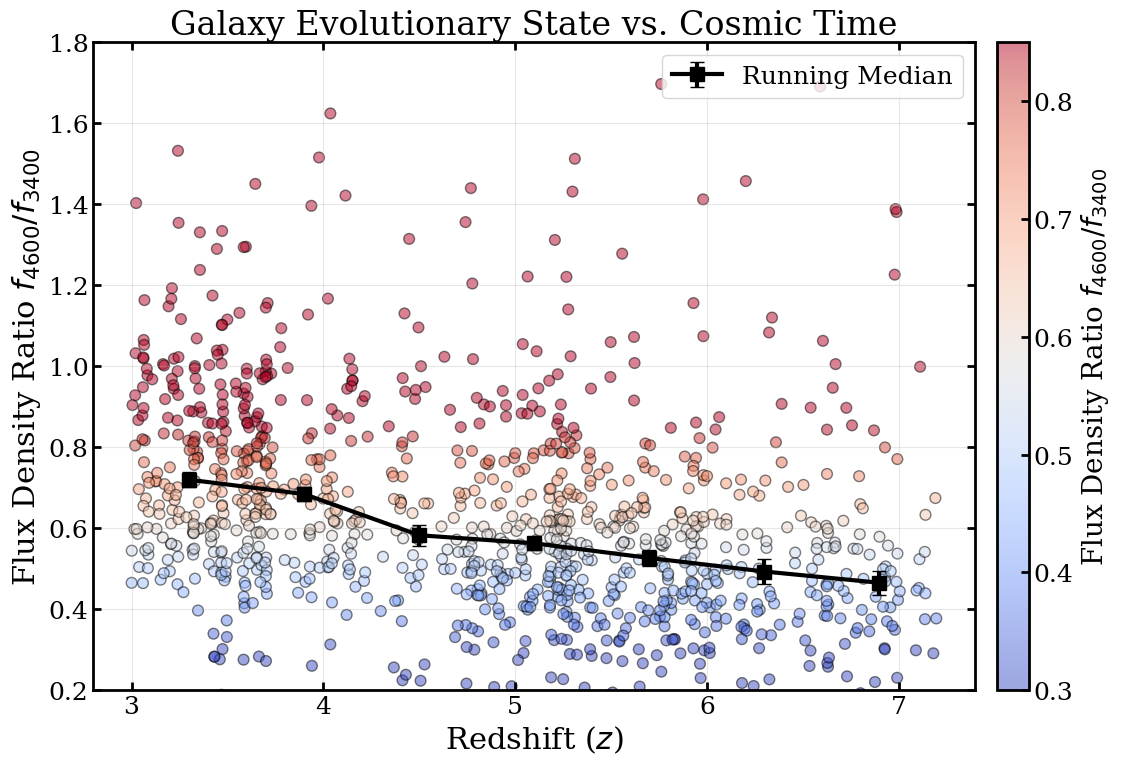

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import binned_statistic

# 设置绘图风格
mpl.rcParams.update({'font.size': 18, 'font.family': 'serif', 'axes.linewidth': 2,
                     'xtick.direction': 'in', 'ytick.direction': 'in', 'figure.figsize': (10, 8)})

z_list = []
dn_list = []

# 提取数据
for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
    if not entry['sample_flag']:
        continue
    try:
        m = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
        dn = m['red_flux_density'] / m['blue_flux_density']
        z = entry['determined_redshift']

        # 限制在合理的物理范围内，剔除极个别极端离群点
        if 0.1 < dn < 2.5 and 3.0 <= z <= 7.2:
            z_list.append(z)
            dn_list.append(dn)
    except:
        continue

z_array = np.array(z_list)
dn_array = np.array(dn_list)

# 计算 Running Median (滑动中位数) 展现趋势
z_bins = np.linspace(3.0, 7.2, 8)
bin_centers = 0.5 * (z_bins[1:] + z_bins[:-1])
dn_median, _, _ = binned_statistic(
    z_array, dn_array, statistic='median', bins=z_bins)
dn_err, _, _ = binned_statistic(
    z_array, dn_array, statistic=lambda x: np.std(x)/np.sqrt(len(x)), bins=z_bins)

fig, ax = plt.subplots(figsize=(12, 8))
# 画散点，用颜色表示 dn 值，直观呼应你曲线图的冷暖色调
scatter = ax.scatter(z_array, dn_array, c=dn_array, cmap='coolwarm',
                     alpha=0.5, edgecolor='k', s=60, vmin=0.3, vmax=0.85)

# 画滑动中位数
ax.errorbar(bin_centers, dn_median, yerr=dn_err, color='black', lw=3, marker='s', markersize=10,
            label='Running Median', capsize=5, zorder=10)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=20)

ax.set_xlabel('Redshift ($z$)', fontsize=22)
ax.set_ylabel(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=22)
ax.set_title('Galaxy Evolutionary State vs. Cosmic Time', fontsize=24)
ax.set_xlim(2.8, 7.4)
ax.set_ylim(0.2, 1.8)
ax.legend(loc='upper right', fontsize=18)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FluxRatio_vs_Redshift.pdf', dpi=300)
plt.show()

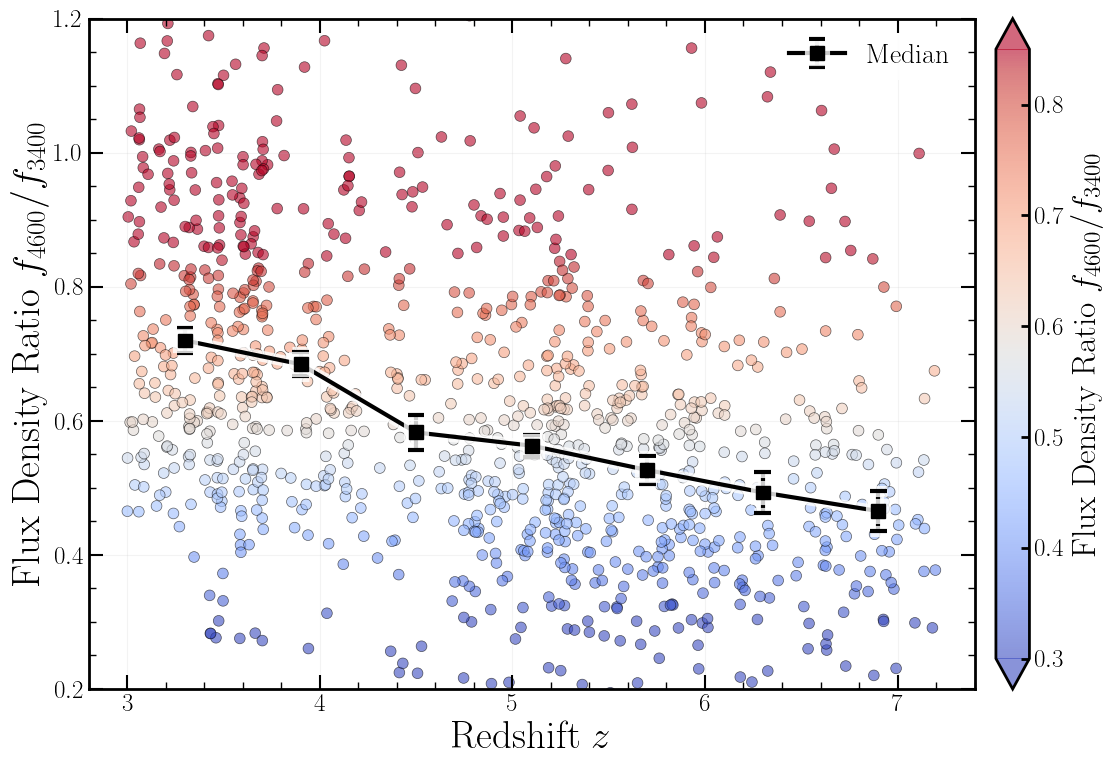

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl

# 1. 确保全局字体设置正确 (纯正 LaTeX 渲染)
mpl.rcParams.update({"mathtext.fontset": "stix", "font.family": "serif"})
mpl.rcParams['text.usetex'] = True
fig, ax = plt.subplots(figsize=(12, 8))

# ==========================================
# 2. 绘制散点图 (优化了边框线宽，使其显得更精致)
# ==========================================
scatter = ax.scatter(z_array, dn_array, c=dn_array, cmap='coolwarm',
                     alpha=0.6,          # 稍微提高一点透明度，让色彩更饱满
                     edgecolor='k',
                     linewidth=0.5,      # 散点边框调细，避免黑色边缘显得太脏
                     s=60,
                     vmin=0.3, vmax=0.85,
                     zorder=1)           # 放在底层

# ==========================================
# 3. 绘制滑动中位数 (重点：带有白色轮廓分离背景)
# ==========================================
# errorbar 返回的是一个容器 (主线, 误差帽, 误差竖线)
eb = ax.errorbar(bin_centers, dn_median, yerr=dn_err,
                 color='black', lw=3, marker='s', markersize=10,
                 elinewidth=3, capsize=6, capthick=3, # 让误差棒本身也粗壮协调
                 label='Median',
                 zorder=10)

# 【高级技巧】：给 errorbar 的所有组件（主线、误差棒、误差帽）统一加上白色描边
white_halo =[pe.Stroke(linewidth=8, foreground='white', alpha=0.8), pe.Normal()]

eb[0].set_path_effects(white_halo)        # 给主折线和 Marker 加白边
for cap in eb[1]:
    cap.set_path_effects(white_halo)      # 给误差帽 (caps) 加白边
for bar in eb[2]:
    bar.set_path_effects(white_halo)      # 给误差竖线 (bars) 加白边

# ==========================================
# 4. Colorbar 设置 (带次级刻度)
# ==========================================
cbar = plt.colorbar(scatter, ax=ax, pad=0.02,extend='both')
cbar.set_label(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=24)
# 给 Colorbar 也加上向内的刻度
# cbar.ax.minorticks_on()
# cbar.ax.tick_params(which='major', length=8, width=1.5, direction='in')
# cbar.ax.tick_params(which='minor', length=4, width=1, direction='in')

# ==========================================
# 5. 坐标轴与刻度美化 (学术标配)
# ==========================================
ax.set_xlabel(r'Redshift $z$', fontsize=28)
ax.set_ylabel(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=28)
# ax.set_title('Galaxy Evolutionary State vs. Cosmic Time', fontsize=24) # 顶级期刊图表通常不加 title，而是写在 Caption 里，可根据需要保留或注释

ax.set_xlim(2.8, 7.4)
ax.set_ylim(0.2, 1.2)

# 开启全包围式的向内主/次刻度
ax.minorticks_on()
ax.tick_params(axis='both', which='major', length=10, width=1.5, direction='in', top=True, right=True)
ax.tick_params(axis='both', which='minor', length=5, width=1, direction='in', top=True, right=True)

# 开启极淡的网格线作为参考
ax.grid(True, alpha=0.15, zorder=0)

# ==========================================
# 6. 图例美化与保存
# ==========================================
ax.legend(loc='upper right',
          fontsize=20,
          framealpha=0.9,     # 略带毛玻璃质感，防止遮挡散点
          edgecolor='none')

plt.tight_layout()
plt.savefig('FluxRatio_vs_Redshift.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl
from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
from scipy.interpolate import interp1d

# ==========================================
# 0. 全局排版设置
# ==========================================
mpl.rcParams.update({"mathtext.fontset": "stix", "font.family": "serif"})
mpl.rcParams['text.usetex'] = True

fig, ax = plt.subplots(figsize=(12, 8))

# ==========================================
# 1. 模拟观测数据 (请替换为你真实的数组)
# ==========================================
# z_array = ...
# dn_array = ...
# mass_array = ...
# bin_centers = ...
# dn_median = ...
# dn_err = ...

# ==========================================
# 2. 准备 Bagpipes 理论模型数据
# ==========================================
# 假设 age_list, res_burst, res_constant, res_delayed 是你刚才跑出来的数组
# 这里使用插值函数，方便我们输入任意年龄直接获取 Ratio
interp_burst = interp1d(age_list, res_burst, bounds_error=False, fill_value=np.nan)
interp_const = interp1d(age_list, res_constant, bounds_error=False, fill_value=np.nan)
interp_delay = interp1d(age_list, res_delayed, bounds_error=False, fill_value=np.nan)

# ==========================================
# 3. 宇宙学时间映射计算
# ==========================================
# 设定星系开始形成的红移 (可根据你的科学目标调整，通常取 10 或 15)
z_form = 10.0
t_form = Planck18.age(z_form).value  # 宇宙在 z=10 时的年龄 (Gyr)

# 生成平滑的观测红移网格用于画理论线
z_grid = np.linspace(2.8, 7.4, 200)
t_obs = Planck18.age(z_grid).value   # 观测红移处的宇宙年龄 (Gyr)

# 星系在观测红移处的最大可能年龄！
t_max_gal = t_obs - t_form

# 获取该红移下，不同SFH模型能达到的理论 Ratio
ratio_burst_max = interp_burst(t_max_gal)
ratio_const_max = interp_const(t_max_gal)
ratio_delay_max = interp_delay(t_max_gal)

# ==========================================
# 4. 绘制观测散点与滑动中位数 (保持之前的高级质感)
# ==========================================
scatter = ax.scatter(z_array, dn_array, c=mass_array, cmap='coolwarm',
                     alpha=0.6, edgecolor='k', linewidth=0.5, s=60,
                     vmin=8.5, vmax=10.0, zorder=1)

eb = ax.errorbar(bin_centers, dn_median, yerr=dn_err,
                 color='black', lw=3, marker='s', markersize=10,
                 elinewidth=3, capsize=6, capthick=3, label='Observed Median', zorder=10)

white_halo =[pe.Stroke(linewidth=8, foreground='white', alpha=0.8), pe.Normal()]
eb[0].set_path_effects(white_halo)
for cap in eb[1]: cap.set_path_effects(white_halo)
for bar in eb[2]: bar.set_path_effects(white_halo)

# ==========================================
# 5. 【核心新增】叠加理论演化边界 (Models)
# ==========================================
# 绘制 Burst (红色包络线)
ax.plot(z_grid, ratio_burst_max, color='#d62728', lw=4, ls='--',
        label=rf'Max Age Burst ($z_{{form}}={z_form}$)', zorder=5,
        path_effects=[pe.Stroke(linewidth=6, foreground='white', alpha=0.5), pe.Normal()])

# 绘制 Delayed tau (中间演化线)
ax.plot(z_grid, ratio_delay_max, color='#2ca02c', lw=3, ls='-.',
        label=r'Max Age Delayed ($\tau=1.5$ Gyr)', zorder=5,
        path_effects=[pe.Stroke(linewidth=5, foreground='white', alpha=0.5), pe.Normal()])

# 绘制 Constant SFH (蓝色基线)
ax.plot(z_grid, ratio_const_max, color='#1f77b4', lw=4, ls=':',
        label=rf'Max Age Constant SFH', zorder=5,
        path_effects=[pe.Stroke(linewidth=6, foreground='white', alpha=0.5), pe.Normal()])

# 可选：将被 Burst 限界的上方区域涂上极淡的阴影，表示 "Forbidden Zone" (无尘埃情况下的禁区)
ax.fill_between(z_grid, ratio_burst_max, 2.0, color='#d62728', alpha=0.05, zorder=0)
ax.text(6.0, ratio_burst_max[-1] + 0.1, r'Dust Required Zone', color='#d62728', fontsize=20, alpha=0.7)

# ==========================================
# 6. 坐标轴、Colorbar 与顶部宇宙时间轴
# ==========================================
# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02, extend='both')
cbar.set_label(r'$\log(M_*/M_\odot)$', fontsize=24)
cbar.ax.minorticks_on()
cbar.ax.tick_params(which='major', length=8, width=1.5, direction='in')
cbar.ax.tick_params(which='minor', length=4, width=1, direction='in')

# 主坐标轴
ax.set_xlabel(r'Redshift $z$', fontsize=28)
ax.set_ylabel(r'Flux Density Ratio $f_{4600}/f_{3400}$', fontsize=28)
ax.set_xlim(2.8, 7.4)
ax.set_ylim(0.2, 1.2)  # 根据加入理论线后可能需要适当放宽上限
ax.minorticks_on()
ax.tick_params(axis='both', which='major', length=10, width=1.5, direction='in', top=False, right=True)
ax.tick_params(axis='both', which='minor', length=5, width=1, direction='in', top=False, right=True)

# 顶部 Cosmic Time 坐标轴
ax2 = ax.twiny()
age_ticks = np.array([0.7, 1.0, 1.5, 2.0])
z_ticks =[z_at_value(Planck18.age, age * u.Gyr).value for age in age_ticks]

ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(z_ticks)
ax2.set_xticklabels([f'${t:.1f}$' for t in age_ticks], fontsize=20)
ax2.set_xlabel(r'Cosmic Time ($\mathrm{Gyr}$)', fontsize=28, labelpad=10)
ax2.minorticks_on()
ax2.tick_params(axis='x', which='major', length=10, width=1.5, direction='in')
ax2.tick_params(axis='x', which='minor', length=5, width=1, direction='in')

ax.grid(True, alpha=0.15, zorder=0)

# 图例分列排版 (Data vs Models)
ax.legend(loc='lower right', fontsize=18, framealpha=0.9, edgecolor='none', ncol=1)

plt.tight_layout()
plt.savefig('FluxRatio_vs_Redshift_with_Models.pdf', dpi=300, bbox_inches='tight')
plt.show()

Running Control Experiment within Redshift bin: 3.0 <= z < 5.0
Processing Dn 0.30-0.55 (z=3.0-5.0) | Total Samples: 143
Categorizing 143 objects...
Group 0: N=12, Mean BD=0.000 +/- 0.005
Group 1: N=23, Mean BD=0.061 +/- 0.005
Group 2: N=24, Mean BD=0.151 +/- 0.006
Group 3: N=21, Mean BD=0.246 +/- 0.007
Group 4: N=6, Mean BD=0.371 +/- 0.016
Group 5: N=3, Mean BD=0.546 +/- 0.022
Group 6: N=4, Mean BD=0.765 +/- 0.019

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Running MCMC with 32 walkers for 2000 steps (Monotonicity Constrained)...


100%|██████████| 2000/2000 [00:01<00:00, 1142.58it/s]


MCMC Best Fit Coeffs: [ 0.00930563 -0.18881088  1.32100652 -1.89502786]
Derived Parameters: S=3.3039, Intercept=-0.89877, Rv=5.159
Processing Dn 0.55-0.70 (z=3.0-5.0) | Total Samples: 144
Categorizing 144 objects...
Group 0: N=14, Mean BD=0.000 +/- 0.005
Group 1: N=22, Mean BD=0.062 +/- 0.005
Group 2: N=28, Mean BD=0.151 +/- 0.005
Group 3: N=14, Mean BD=0.243 +/- 0.007
Group 4: N=15, Mean BD=0.348 +/- 0.010
Group 5: N=8, Mean BD=0.495 +/- 0.015
Group 6: N=1, Mean BD=0.849 +/- 0.085

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Running MCMC with 32 walkers for 2000

100%|██████████| 2000/2000 [00:01<00:00, 1073.49it/s]


MCMC Best Fit Coeffs: [ 0.01070298 -0.16527675  1.01177719 -1.43334276]
Derived Parameters: S=4.6755, Intercept=-0.89877, Rv=5.448
Processing Dn 0.70-2.00 (z=3.0-5.0) | Total Samples: 241
Categorizing 241 objects...
Group 0: N=18, Mean BD=0.000 +/- 0.004
Group 1: N=25, Mean BD=0.061 +/- 0.005
Group 2: N=37, Mean BD=0.143 +/- 0.005
Group 3: N=29, Mean BD=0.249 +/- 0.006
Group 4: N=24, Mean BD=0.363 +/- 0.009
Group 5: N=11, Mean BD=0.521 +/- 0.011
Group 6: N=12, Mean BD=0.710 +/- 0.028

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Running MCMC with 32 walkers for 20

100%|██████████| 2000/2000 [00:01<00:00, 1155.82it/s]


MCMC Best Fit Coeffs: [ 0.00173275 -0.08438852  1.07087434 -1.62412695]
Derived Parameters: S=2.9432, Intercept=-0.89877, Rv=4.041


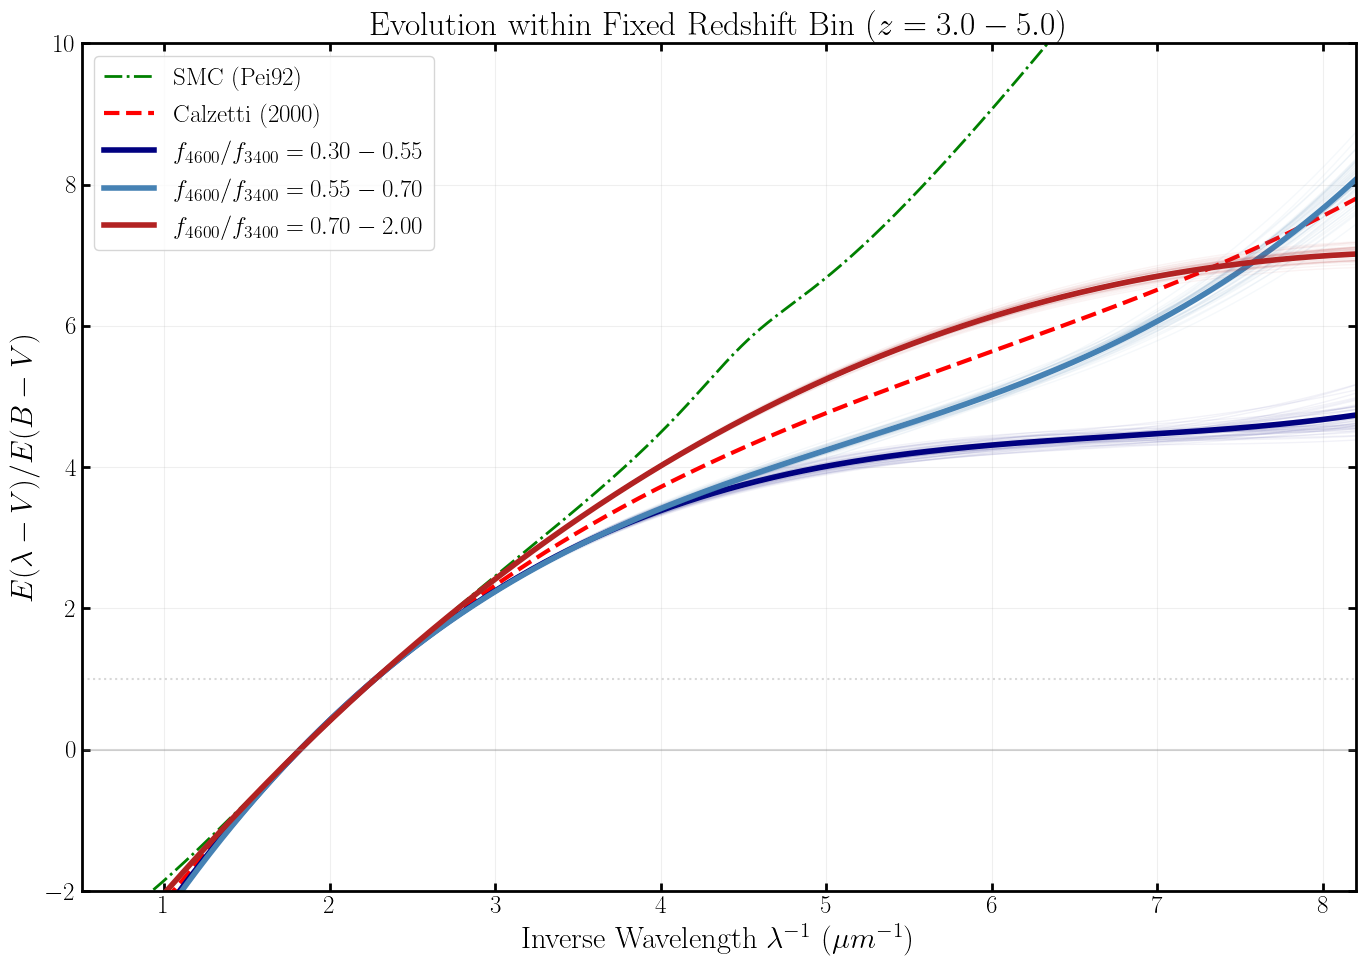

In [21]:
# ==========================================
# 控制变量实验：固定 Redshift，只改变 Flux Ratio
# ==========================================
z_min, z_max = 3.00, 5.00
print(
    f"Running Control Experiment within Redshift bin: {z_min} <= z < {z_max}")

# 重新初始化 Analyst（假设你已经导入了你修改好的 FunctionLibChange 作为 FL）
analyst_controlled = []
dn_index_conditions_controlled = np.array(
    [[0.30, 0.55], [0.55, 0.70], [0.70, 2.00]])  # 为了保证统计量，把最高两个红bin合并


def dn_condition_func_ctrl(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions_controlled):
        if low <= dn_index < high:
            return i
    return -1


colors_ctrl = ['navy', 'steelblue', 'firebrick']

for dn_idx in range(len(dn_index_conditions_controlled)):
    dn_range = dn_index_conditions_controlled[dn_idx]
    condition_name = f"Dn {dn_range[0]:.2f}-{dn_range[1]:.2f} (z={z_min}-{z_max})"

    # 筛选符合条件的 ID 列表
    surveyid_subid_list = []
    for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
        if not entry['sample_flag']:
            continue

        try:
            # 1. 先卡 Redshift
            z = entry['determined_redshift']
            if not (z_min <= z < z_max):
                continue

            # 2. 再卡 Flux Ratio
            m = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
            dn_index = m['red_flux_density'] / m['blue_flux_density']
            if dn_condition_func_ctrl(dn_index) != dn_idx:
                continue

            surveyid_subid_list.append(surveyid_subid)
        except KeyError:
            continue

    print(
        f"Processing {condition_name} | Total Samples: {len(surveyid_subid_list)}")

    if len(surveyid_subid_list) < 20:
        print("  -> Warning: Too few samples, skipping this bin.")
        continue

    # 运行管线
    analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)
    analyst.load_and_group_objects(surveyid_subid_list)
    analyst.compute_average_spectra()

    try:
        analyst.compute_smooth_reference(window_len=51, poly_order=3)
        analyst.compute_attenuation_curves(mode='smoothed')
        analyst.run_mcmc_fitting(nwalkers=32, nsteps=2000, poly_order=3)
        analyst.derive_k_curve_parameters(intercept_val=-0.89877)
        analyst.plot_label = f"$f_{{4600}}/f_{{3400}} = {dn_range[0]:.2f}-{dn_range[1]:.2f}$"
        analyst.plot_color = colors_ctrl[dn_idx]
        analyst_controlled.append(analyst)
    except Exception as e:
        print(f"  -> Failed to compute curve for {condition_name}: {e}")

# ==========================================
# 绘制 Controlled Reddening Curve
# ==========================================
fig, ax = plt.subplots(figsize=(14, 10))

# 画背景参考线
x_grid = np.linspace(0.5, 8.2, 1000)
y_calz = FL.DustAttenuationAnalyst._get_normalized_reddening(
    x_grid, 'calzetti')
y_smc = FL.DustAttenuationAnalyst._get_normalized_reddening(x_grid, 'smc')
ax.plot(x_grid, y_smc, color='green', ls='-.', lw=2, label='SMC (Pei92)')
ax.plot(x_grid, y_calz, color='red', ls='--', lw=3, label='Calzetti (2000)')

# 画各组数据
for ana in analyst_controlled:
    # 取 MCMC median coefficients 画形状
    shape_grid = ana._poly_shape_cubic_only(x_grid)
    shape_V = ana._poly_shape_cubic_only(1.0/0.55)
    shape_B = ana._poly_shape_cubic_only(1.0/0.44)
    y_plot = (shape_grid - shape_V) / (shape_B - shape_V)

    ax.plot(x_grid, y_plot, color=ana.plot_color, lw=4, label=ana.plot_label)

    # 画几个 MCMC sample 表示误差
    if hasattr(ana, 'mcmc_samples'):
        inds = np.random.randint(len(ana.mcmc_samples), size=50)
        for ind in inds:
            c3, c2, c1, _ = ana.mcmc_samples[ind]
            def s_func(x): return c3*x**3 + c2*x**2 + c1*x
            v_grid = s_func(x_grid)
            v_B = s_func(1.0/0.44)
            v_V = s_func(1.0/0.55)
            ax.plot(x_grid, (v_grid - v_V)/(v_B - v_V),
                    color=ana.plot_color, alpha=0.05, lw=1)

ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=22)
ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=22)
ax.set_title(
    f'Evolution within Fixed Redshift Bin ($z={z_min}-{z_max}$)', fontsize=24)
ax.set_xlim(0.5, 8.2)
ax.set_ylim(-2, 10)
ax.axhline(0, color='gray', alpha=0.3)
ax.axhline(1, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=18, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('Controlled_Reddening_z3.pdf', dpi=300)
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

def custom_plot_reddening_curve_comparison(analyst,
                                           if_show=True,
                                           if_input=False,
                                           fig=None,
                                           ax=None,
                                           curve_label='This Study',
                                           curve_color='#002147',
                                           curve_linestyle='-',
                                           draw_background=True,
                                           plot_mcmc_samples=False,
                                           n_samples=100):
    """
    外部重写的绘制红化对比图函数。
    【修改内容】：MCMC 样本线使用主线同色，且不再进入图例。
    """
    if analyst.scaling_factor is None:
        analyst.derive_k_curve_parameters()

    if if_input:
        if fig is None or ax is None:
            raise ValueError("If if_input is True, fig and ax must be provided.")
    else:
        fig, ax = plt.subplots(figsize=(12, 10))
        draw_background = True

    x_grid = np.linspace(0.5, 8.2, 1000) # 1/um

    # ==========================================
    # 3. 准备 MCMC 样本线
    # ==========================================
    sample_lines_y =[]
    if plot_mcmc_samples and hasattr(analyst, 'mcmc_samples'):
        x_B, x_V = 1.0/0.44, 1.0/0.55
        n_total = len(analyst.mcmc_samples)

        actual_n = min(n_samples, n_total)
        inds = np.random.choice(n_total, size=actual_n, replace=False)

        for ind in inds:
            coeffs = analyst.mcmc_samples[ind]
            c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]

            def shape_func(x):
                return c3 * x**3 + c2 * x**2 + c1 * x

            val_grid = shape_func(x_grid)
            val_B = shape_func(x_B)
            val_V = shape_func(x_V)

            y_sample = (val_grid - val_V) / (val_B - val_V)
            sample_lines_y.append(y_sample)

    # ==========================================
    # 4. 计算最佳拟合曲线 (Best Fit)
    # ==========================================
    shape_grid = analyst._poly_shape_cubic_only(x_grid)
    shape_V = analyst._poly_shape_cubic_only(1.0/0.55)
    shape_B = analyst._poly_shape_cubic_only(1.0/0.44)
    y_derived = (shape_grid - shape_V) / (shape_B - shape_V)

    # ==========================================
    # 5. 绘制背景参考线
    # ==========================================
    if draw_background:
        y_calz = analyst._get_normalized_reddening(x_grid, 'calzetti')
        y_mw = analyst._get_normalized_reddening(x_grid, 'mw')
        y_smc = analyst._get_normalized_reddening(x_grid, 'smc')

        ax.plot(x_grid, y_mw, color='#1f77b4', ls=':', lw=3, label='Milky Way (CCM89)')
        ax.plot(x_grid, y_smc, color='#2ca02c', ls='-.', lw=3, label='SMC (Pei92)')
        ax.plot(x_grid, y_calz, color='#d62728', ls='--', lw=3, label='Calzetti (2000)')

        # 辅助线和标记
        x_V, x_B = 1.0/0.55, 1.0/0.44
        ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(x_V, color='gray', linestyle='-', alpha=0.3)
        ax.scatter([x_V], [0], color='black', s=80, zorder=10)
        ax.text(x_V, 0.5, r'V ($5500\,\mathrm{\AA}$)', rotation=90, color='gray', fontsize=20, ha='right')

        ax.axhline(1, color='gray', linestyle=':', alpha=0.3)
        ax.axvline(x_B, color='gray', linestyle=':', alpha=0.3)
        ax.scatter([x_B], [1], color='black', s=80, zorder=10)
        ax.text(x_B, 1.5, r'B ($4400\,\mathrm{\AA}$)', rotation=90, color='gray', fontsize=20, ha='right')

        # 顶部波长轴
        ax2 = ax.twiny()
        ticks =[10000, 5500, 4400, 3000, 2000, 1500]
        ax2.set_xlim(0.5, 8.2)
        ax2.set_xticks([10000.0/t for t in ticks])
        ax2.set_xticklabels([str(t) for t in ticks], fontsize=18)
        ax2.set_xlabel(r'Wavelength $\lambda\ (\mathrm{\AA})$', fontsize=28)

        # 开启次级刻度
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', length=8, width=1.5, direction='in', right=True)
        ax.tick_params(axis='both', which='minor', length=4, width=1, direction='in', right=True)
        ax2.minorticks_on()
        ax2.tick_params(axis='x', which='major', length=8, width=1.5, direction='in')
        ax2.tick_params(axis='x', which='minor', length=4, width=1, direction='in')

        ax.grid(True, alpha=0.2)

    # ==========================================
    # 6. 绘制 MCMC 样本线 (在底层)
    # ==========================================
    if sample_lines_y:
        for y_samp in sample_lines_y:
            ax.plot(x_grid, y_samp,
                    color=curve_color,   # 【修改点】：直接使用传入的主线颜色
                    alpha=0.03,          # 透明度保持极低
                    lw=1.5,
                    zorder=1)            # 【修改点】：不再包含 label 属性

    # ==========================================
    # 7. 绘制最佳拟合线 (带有白色外轮廓 alpha=0.25)
    # ==========================================
    ax.plot(x_grid, y_derived,
            color=curve_color,
            linestyle=curve_linestyle,
            lw=4,
            label=curve_label,
            zorder=5,
            path_effects=[pe.Stroke(linewidth=8, foreground='white', alpha=0.5), pe.Normal()])

    if if_show:
        # 单独显示时的逻辑
        ax.set_xlim(0.5, 8.2)
        ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}\ (\mu\mathrm{m}^{-1})$', fontsize=28)
        ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=28)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left', framealpha=0.9, edgecolor='none')
        plt.tight_layout()
        plt.show()

    return fig, ax

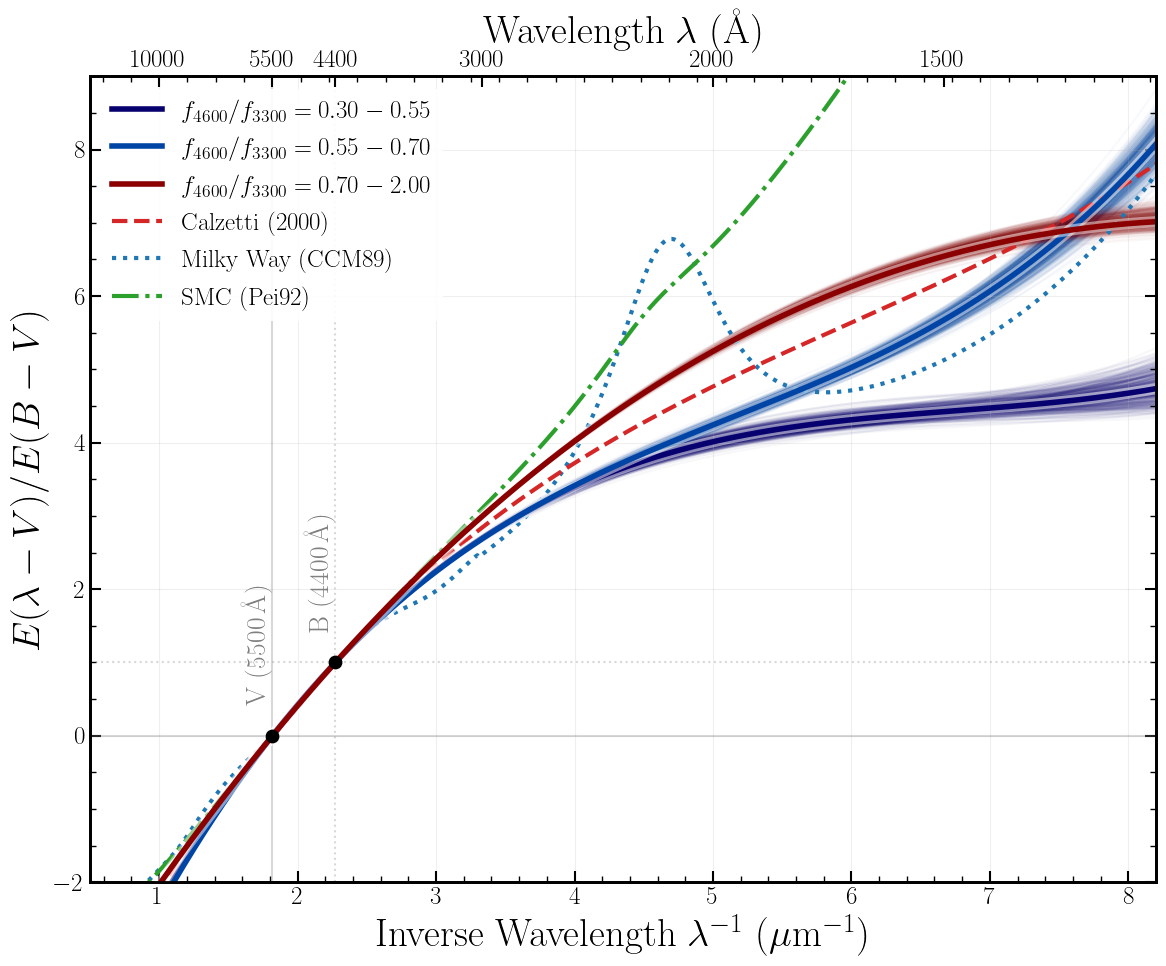

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))

# 【修改点】：定制你的四个颜色：深蓝 -> 浅蓝 -> 金黄 -> 红色
# 必须确保 analyst_list 的长度为 4 才能一一对应
custom_colors =["#07006F", "#0045A5", "#8B0000"]
custom_linestyles = ['-', '-', '-']

for i, analyst in enumerate(analyst_controlled):
    dn_index_range = dn_index_conditions_controlled[i]
    condition_name = f"$f_{{4600}}/f_{{3300}} = {dn_index_range[0]:.2f} - {dn_index_range[1]:.2f}$"

    # 确保不越界，如果有多于4个bin可以循环使用颜色：custom_colors[i % len(custom_colors)]
    current_color = custom_colors[i]
    current_linestyle = custom_linestyles[i]

    custom_plot_reddening_curve_comparison(analyst,if_show=False,if_input=True,
                                           fig=fig,
                                           ax=ax,
                                           curve_label=condition_name,
                                           curve_color=current_color,
                                           curve_linestyle=current_linestyle,
                                           draw_background=(i==0),  # 只在第一条线时画背景参考线
                                           plot_mcmc_samples=True,   # 画 MCMC 样本线
                                           n_samples=500)           # 限制样本线数量，保持图像清晰

ax.set_xlim(0.5, 8.2)
ax.set_ylim(-2, 9)
ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}\ (\mu\mathrm{m}^{-1})$', fontsize=28)
ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=28)


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))


# 【修改点】：这里不再包含 'MCMC Samples'
ordered_keys =[lbl for lbl in labels if "f_{4600}/f_{3300}" in lbl] +['Calzetti (2000)', 'Milky Way (CCM89)', 'SMC (Pei92)']

ordered_handles = [by_label[k] for k in ordered_keys if k in by_label]
ordered_labels = [k for k in ordered_keys if k in by_label]

ax.legend(ordered_handles, ordered_labels,
          loc='upper left',
          fontsize=18,
          framealpha=0.9,
          edgecolor='none')

plt.tight_layout()

fig.savefig('Controlled_Reddening_z3_Enhanced.pdf', dpi=300, bbox_inches='tight')
plt.show()

Running Control Experiment within Redshift bin: 5.0 <= z < 7.2
Processing Dn 0.30-0.55 (z=5.0-7.2) | Total Samples: 235
Categorizing 235 objects...
Group 0: N=22, Mean BD=0.000 +/- 0.004
Group 1: N=35, Mean BD=0.067 +/- 0.004
Group 2: N=21, Mean BD=0.143 +/- 0.005
Group 3: N=23, Mean BD=0.238 +/- 0.006
Group 4: N=8, Mean BD=0.369 +/- 0.015
Group 5: N=8, Mean BD=0.513 +/- 0.013
Group 6: N=9, Mean BD=0.693 +/- 0.020

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Running MCMC with 32 walkers for 2000 steps (Monotonicity Constrained)...


100%|██████████| 2000/2000 [00:01<00:00, 1088.97it/s]


MCMC Best Fit Coeffs: [ 0.01843665 -0.27433298  1.3999629  -1.93339421]
Derived Parameters: S=4.3133, Intercept=-0.89877, Rv=6.646
Processing Dn 0.55-0.70 (z=5.0-7.2) | Total Samples: 127
Categorizing 127 objects...
Group 0: N=15, Mean BD=0.000 +/- 0.006
Group 1: N=19, Mean BD=0.057 +/- 0.005
Group 2: N=19, Mean BD=0.142 +/- 0.005
Group 3: N=12, Mean BD=0.238 +/- 0.008
Group 4: N=3, Mean BD=0.320 +/- 0.011
Group 5: N=7, Mean BD=0.542 +/- 0.015
Group 6: N=4, Mean BD=0.687 +/- 0.010

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Running MCMC with 32 walkers for 2000 

100%|██████████| 2000/2000 [00:01<00:00, 1089.70it/s]


MCMC Best Fit Coeffs: [ 0.03005035 -0.453116    2.39601383 -2.85598484]
Derived Parameters: S=2.3885, Intercept=-0.89877, Rv=6.360
Processing Dn 0.70-2.00 (z=5.0-7.2) | Total Samples: 110
Categorizing 110 objects...
Group 0: N=9, Mean BD=0.000 +/- 0.006
Group 1: N=15, Mean BD=0.060 +/- 0.006
Group 2: N=11, Mean BD=0.138 +/- 0.008
Group 3: N=6, Mean BD=0.263 +/- 0.010
Group 4: N=8, Mean BD=0.376 +/- 0.019
Group 5: N=4, Mean BD=0.486 +/- 0.018
Group 6: N=2, Mean BD=0.892 +/- 0.029

Computing average spectra...
Applied masks to 9 regions.
  Group 0: Processed.
Applied masks to 9 regions.
  Group 1: Processed.
Applied masks to 9 regions.
  Group 2: Processed.
Applied masks to 9 regions.
  Group 3: Processed.
Applied masks to 9 regions.
  Group 4: Processed.
Applied masks to 9 regions.
  Group 5: Processed.
Applied masks to 9 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve with FULL error propagation (Flux + Tau).
Running MCMC with 32 walkers for 2000 st

100%|██████████| 2000/2000 [00:01<00:00, 1055.16it/s]


MCMC Best Fit Coeffs: [ 0.03321421 -0.53756068  3.17641054 -4.41704087]
Derived Parameters: S=1.5760, Intercept=-0.89877, Rv=5.717


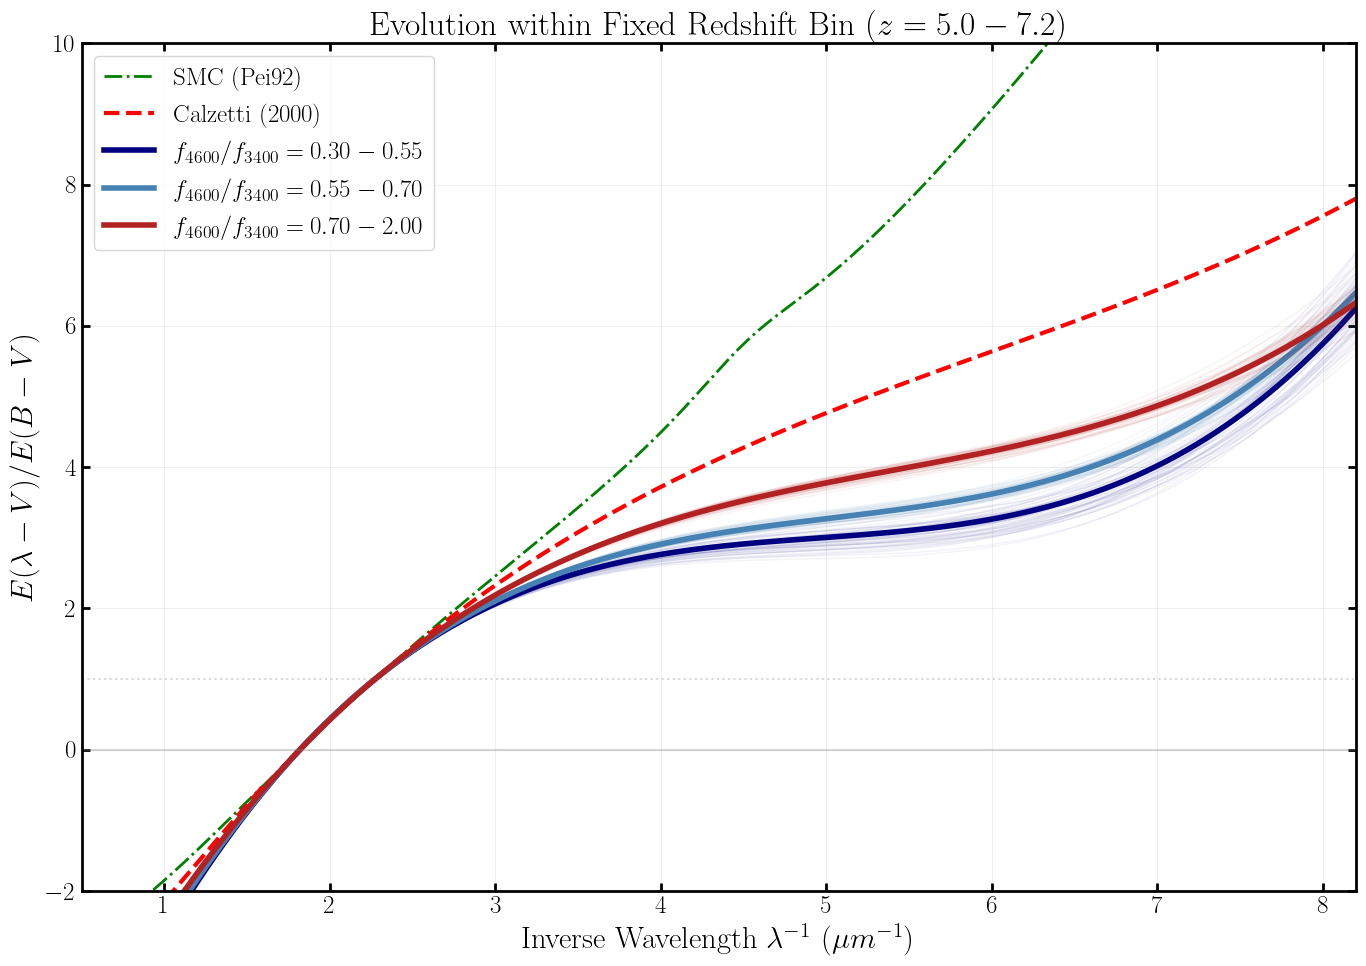

In [26]:
# ==========================================
# 控制变量实验：固定 Redshift，只改变 Flux Ratio
# ==========================================
z_min, z_max = 5.00, 7.20
print(
    f"Running Control Experiment within Redshift bin: {z_min} <= z < {z_max}")

# 重新初始化 Analyst（假设你已经导入了你修改好的 FunctionLibChange 作为 FL）
analyst_controlled = []
dn_index_conditions_controlled = np.array(
    [[0.30, 0.55], [0.55, 0.70], [0.70, 2.00]])  # 为了保证统计量，把最高两个红bin合并


def dn_condition_func_ctrl(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions_controlled):
        if low <= dn_index < high:
            return i
    return -1


colors_ctrl = ['navy', 'steelblue', 'firebrick']

for dn_idx in range(len(dn_index_conditions_controlled)):
    dn_range = dn_index_conditions_controlled[dn_idx]
    condition_name = f"Dn {dn_range[0]:.2f}-{dn_range[1]:.2f} (z={z_min}-{z_max})"

    # 筛选符合条件的 ID 列表
    surveyid_subid_list = []
    for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
        if not entry['sample_flag']:
            continue

        try:
            # 1. 先卡 Redshift
            z = entry['determined_redshift']
            if not (z_min <= z < z_max):
                continue

            # 2. 再卡 Flux Ratio
            m = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
            dn_index = m['red_flux_density'] / m['blue_flux_density']
            if dn_condition_func_ctrl(dn_index) != dn_idx:
                continue

            surveyid_subid_list.append(surveyid_subid)
        except KeyError:
            continue

    print(
        f"Processing {condition_name} | Total Samples: {len(surveyid_subid_list)}")

    if len(surveyid_subid_list) < 20:
        print("  -> Warning: Too few samples, skipping this bin.")
        continue

    # 运行管线
    analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)
    analyst.load_and_group_objects(surveyid_subid_list)
    analyst.compute_average_spectra()

    try:
        analyst.compute_smooth_reference(window_len=51, poly_order=3)
        analyst.compute_attenuation_curves(mode='smoothed')
        analyst.run_mcmc_fitting(nwalkers=32, nsteps=2000, poly_order=3)
        analyst.derive_k_curve_parameters(intercept_val=-0.89877)
        analyst.plot_label = f"$f_{{4600}}/f_{{3400}} = {dn_range[0]:.2f}-{dn_range[1]:.2f}$"
        analyst.plot_color = colors_ctrl[dn_idx]
        analyst_controlled.append(analyst)
    except Exception as e:
        print(f"  -> Failed to compute curve for {condition_name}: {e}")

# ==========================================
# 绘制 Controlled Reddening Curve
# ==========================================
fig, ax = plt.subplots(figsize=(14, 10))

# 画背景参考线
x_grid = np.linspace(0.5, 8.2, 1000)
y_calz = FL.DustAttenuationAnalyst._get_normalized_reddening(
    x_grid, 'calzetti')
y_smc = FL.DustAttenuationAnalyst._get_normalized_reddening(x_grid, 'smc')
ax.plot(x_grid, y_smc, color='green', ls='-.', lw=2, label='SMC (Pei92)')
ax.plot(x_grid, y_calz, color='red', ls='--', lw=3, label='Calzetti (2000)')

# 画各组数据
for ana in analyst_controlled:
    # 取 MCMC median coefficients 画形状
    shape_grid = ana._poly_shape_cubic_only(x_grid)
    shape_V = ana._poly_shape_cubic_only(1.0/0.55)
    shape_B = ana._poly_shape_cubic_only(1.0/0.44)
    y_plot = (shape_grid - shape_V) / (shape_B - shape_V)

    ax.plot(x_grid, y_plot, color=ana.plot_color, lw=4, label=ana.plot_label)

    # 画几个 MCMC sample 表示误差
    if hasattr(ana, 'mcmc_samples'):
        inds = np.random.randint(len(ana.mcmc_samples), size=50)
        for ind in inds:
            c3, c2, c1, _ = ana.mcmc_samples[ind]
            def s_func(x): return c3*x**3 + c2*x**2 + c1*x
            v_grid = s_func(x_grid)
            v_B = s_func(1.0/0.44)
            v_V = s_func(1.0/0.55)
            ax.plot(x_grid, (v_grid - v_V)/(v_B - v_V),
                    color=ana.plot_color, alpha=0.05, lw=1)

ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=22)
ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=22)
ax.set_title(
    f'Evolution within Fixed Redshift Bin ($z={z_min}-{z_max}$)', fontsize=24)
ax.set_xlim(0.5, 8.2)
ax.set_ylim(-2, 10)
ax.axhline(0, color='gray', alpha=0.3)
ax.axhline(1, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=18, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('Controlled_Reddening_z3.pdf', dpi=300)
plt.show()

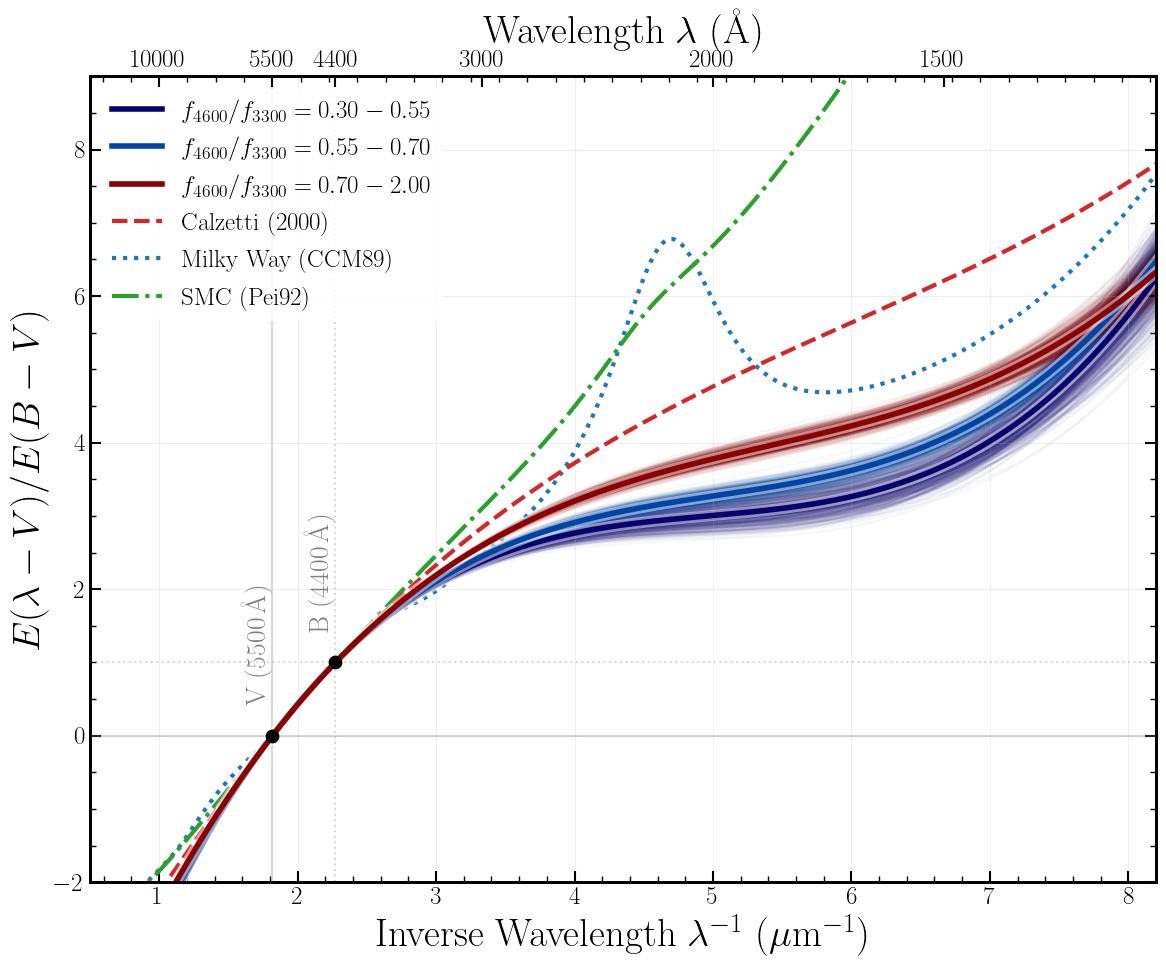

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))

# 【修改点】：定制你的四个颜色：深蓝 -> 浅蓝 -> 金黄 -> 红色
# 必须确保 analyst_list 的长度为 4 才能一一对应
custom_colors =["#07006F", "#0045A5", "#8B0000"]
custom_linestyles = ['-', '-', '-']

for i, analyst in enumerate(analyst_controlled):
    dn_index_range = dn_index_conditions_controlled[i]
    condition_name = f"$f_{{4600}}/f_{{3300}} = {dn_index_range[0]:.2f} - {dn_index_range[1]:.2f}$"

    # 确保不越界，如果有多于4个bin可以循环使用颜色：custom_colors[i % len(custom_colors)]
    current_color = custom_colors[i]
    current_linestyle = custom_linestyles[i]

    custom_plot_reddening_curve_comparison(analyst,if_show=False,if_input=True,
                                           fig=fig,
                                           ax=ax,
                                           curve_label=condition_name,
                                           curve_color=current_color,
                                           curve_linestyle=current_linestyle,
                                           draw_background=(i==0),  # 只在第一条线时画背景参考线
                                           plot_mcmc_samples=True,   # 画 MCMC 样本线
                                           n_samples=500)           # 限制样本线数量，保持图像清晰

ax.set_xlim(0.5, 8.2)
ax.set_ylim(-2, 9)
ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}\ (\mu\mathrm{m}^{-1})$', fontsize=28)
ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=28)


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))


# 【修改点】：这里不再包含 'MCMC Samples'
ordered_keys =[lbl for lbl in labels if "f_{4600}/f_{3300}" in lbl] +['Calzetti (2000)', 'Milky Way (CCM89)', 'SMC (Pei92)']

ordered_handles = [by_label[k] for k in ordered_keys if k in by_label]
ordered_labels = [k for k in ordered_keys if k in by_label]

ax.legend(ordered_handles, ordered_labels,
          loc='upper left',
          fontsize=18,
          framealpha=0.9,
          edgecolor='none')

plt.tight_layout()

fig.savefig('Controlled_Reddening_z5_Enhanced.pdf', dpi=300, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Redshift (z)')

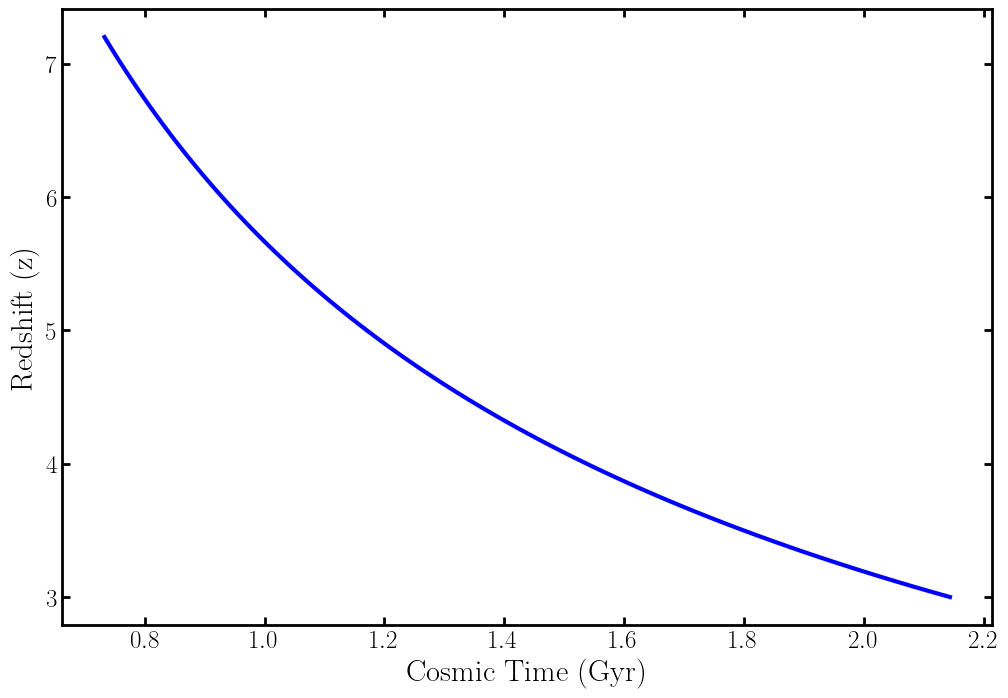

In [28]:
#covert redshift 3 into cosmic time
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

z_values = np.linspace(3, 7.2, 100)
cosmic_time = cosmo.age(z_values).to(u.Gyr)
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(cosmic_time, z_values, color='blue', lw=3)
ax.set_xlabel('Cosmic Time (Gyr)', fontsize=22)
ax.set_ylabel('Redshift (z)', fontsize=22)